# Infrações de Trânsito no Distrito Federal (2018–2025)
### Projeto Final — Introdução à Ciência de Dados · CEUB

**Trio:** Paulo Henrique Pereira Couto Cabral Filho · Arthur Novais Vieira · Rafael Robson Nunes de Araújo

**Fonte dos dados:** Portal de Dados Abertos do DF — *Infrações de Trânsito (DER-DF)*
🔗 https://www.dados.df.gov.br/dataset/infracoes-transito

---

## Pergunta orientadora

> **Como o número de infrações de trânsito no DF evoluiu ao longo dos anos (2018–2025)?**

**Perguntas secundárias**
1. Quais são os tipos de infração mais frequentes no DF?
2. Quais meses apresentam maior quantidade de infrações registradas?
3. Como as infrações se distribuem por gravidade, tipo de veículo e hora do dia?

---

### Como rodar
1. Coloque os 83 arquivos `.csv` originais (descompactados do dataset do portal) numa pasta `dados/`.
2. Ajuste a variável `PASTA_DADOS` na primeira célula de código, se necessário.
3. Execute *Run All*.

> **Nota de engenharia.** O dataset bruto tem **~6,5 milhões de linhas** em 83 CSVs. Carregar tudo de
> uma vez é pesado e desnecessário aqui. O notebook usa **agregação incremental**: processa um arquivo
> por vez, acumula apenas as **contagens** que alimentam os gráficos e descarta as linhas. O pico de
> memória fica em torno de **300 MB**, então roda até em máquinas modestas e no Google Colab gratuito.

## 0. Configuração do ambiente

In [1]:
import os
import glob
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150,
    "axes.titleweight": "bold", "font.size": 11,
})

# Paleta institucional (azul DER-DF + vermelho de alerta de trânsito)
PALETA = "#1B3B6F"
ACENTO = "#C1121F"

# >>> Ajuste aqui o caminho para a pasta com os 83 CSVs do portal <<<
PASTA_DADOS = "/home/claude/data"

def milhar(x, _):
    return f"{int(x):,}".replace(",", ".")

## 1. Entendimento e descrição do conjunto de dados

O dataset do DER-DF é distribuído como **um arquivo CSV por mês**, de julho/2018 a abril/2026.
Ao inspecionar os arquivos, encontramos **5 variações de formato** que precisam ser tratadas no
carregamento — exatamente o tipo de "dado real e bruto" que o projeto pede para enfrentar:

| Variação | Qtd. arquivos | Problema |
|---|---|---|
| Padrão (13 colunas, `;`, UTF-8) | 50 | — |
| Header com aspas (`"col"`) | 24 | aspas no nome das colunas |
| Separador vírgula (`,`) | 2 | separador diferente |
| Apenas 11 colunas | 6 | faltam `latitude`/`longitude` |
| 6 colunas, ISO-8859-1, coluna `dt_cometimento` | 1 | encoding e nome de coluna diferentes |

### Dicionário de dados (colunas usadas na análise)

| Coluna original | Significado | Tipo |
|---|---|---|
| `descricao` | Descrição textual da infração | categórico/texto |
| `tipo_veiculo` | Automóvel, motocicleta, caminhão... | categórico |
| `cometimento` (`dt_cometimento`) | Data do cometimento (`DD/MM/AAAA`) | data |
| `hora_cometimento` | Hora do cometimento (`HH:MM`) | hora |
| `grav_tipo` | Gravidade: Leve, Média, Grave, Gravíssima | categórico ordinal |

As colunas `auinf_local_*` (rodovia, km, latitude, longitude, referência, complemento) descrevem o
local, mas vêm majoritariamente vazias e/ou em formato inconsistente — **não são usadas** nesta análise.

In [2]:
# Funções de leitura robustas: lidam com encoding, separador e nomes de coluna variáveis

RENOMEAR = {
    "dt_cometimento": "cometimento",
    "cometimento": "data", "hora_cometimento": "hora",
    "grav_tipo": "gravidade",
}
USAR = ["descricao", "tipo_veiculo", "data", "hora", "gravidade"]

def detectar_encoding(caminho):
    """Tenta UTF-8; cai para ISO-8859-1 se houver byte inválido."""
    with open(caminho, "rb") as fh:
        amostra = fh.read(8192)
    try:
        amostra.decode("utf-8")
        return "utf-8"
    except UnicodeDecodeError:
        return "iso-8859-1"

def ler_csv(caminho):
    """Lê um CSV do portal padronizando encoding, separador e nomes de coluna."""
    enc = detectar_encoding(caminho)
    with open(caminho, encoding=enc) as fh:
        primeira = fh.readline()
    sep = "," if primeira.count(",") > primeira.count(";") else ";"

    df = pd.read_csv(caminho, sep=sep, encoding=enc, dtype=str,
                     on_bad_lines="skip", quotechar='"')
    df.columns = [c.strip().strip('"').lower() for c in df.columns]
    df = df.rename(columns=RENOMEAR)
    for col in USAR:
        if col not in df.columns:
            df[col] = pd.NA
    return df[USAR]

In [3]:
# Funções de limpeza/normalização aplicadas a cada arquivo

def corrigir_encoding(s):
    """Conserta mojibake (texto latin1 lido como utf-8), ex.: 'MÃ©dia' -> 'Média'."""
    if not isinstance(s, str):
        return s
    try:
        return s.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s

def normalizar_veiculo(s):
    """Unifica grafias e truncamentos: AUTOMOVEL/AUTOMÓVEL -> 'Automóvel', etc."""
    s = corrigir_encoding(str(s)).upper().strip()
    if s.startswith("AUTOM"):
        return "Automóvel"
    if s.startswith("CAMINHO") or s.startswith("CAMION"):
        return "Camionete/Caminhonete"
    if s.startswith("MOTOCI"):
        return "Motocicleta"
    if s.startswith("UTILIT"):
        return "Utilitário"
    if s.startswith("CAMINH"):
        return "Caminhão"
    if s.startswith("ONIBUS") or s.startswith("ÔNIBUS"):
        return "Ônibus"
    if s in ("", "NAN", "NONE"):
        return "Não informado"
    return s.capitalize()

### Carregamento e agregação incremental

Em vez de empilhar 6,5 milhões de linhas na memória, percorremos os arquivos **um a um**. Para cada
arquivo aplicamos a limpeza e somamos as contagens em acumuladores (`Counter`). Ao final, temos todas
as tabelas necessárias para os gráficos — e as métricas de qualidade (linhas totais, datas inválidas).

In [4]:
arquivos = sorted(glob.glob(os.path.join(PASTA_DADOS, "*.csv")))
print(f"Arquivos encontrados: {len(arquivos)}")

# Acumuladores
c_ano, c_mes = Counter(), Counter()
c_desc, c_grav, c_veic, c_hora = Counter(), Counter(), Counter(), Counter()

linhas_brutas = 0
datas_invalidas = 0
nulos_por_coluna = Counter()
preview = None  # primeiras linhas, para exibir o head()

for caminho in arquivos:
    df = ler_csv(caminho)
    if preview is None:
        preview = df.head()

    linhas_brutas += len(df)
    for col in USAR:
        nulos_por_coluna[col] += int(df[col].isna().sum())

    # data -> datetime; conta inválidas; recorta 2018–2025 (2026 incompleto)
    dt = pd.to_datetime(df["data"].astype(str).str.strip(),
                        format="%d/%m/%Y", errors="coerce")
    datas_invalidas += int(dt.isna().sum())
    val = dt.notna() & (dt.dt.year >= 2018) & (dt.dt.year <= 2025)
    df, dt = df[val], dt[val]

    # agrega
    c_ano.update(dt.dt.year.tolist())
    c_mes.update(dt.dt.month.tolist())
    c_desc.update(df["descricao"].astype(str).map(corrigir_encoding).str.strip().tolist())
    c_grav.update(df["gravidade"].astype(str).map(corrigir_encoding).str.strip().tolist())
    c_veic.update(df["tipo_veiculo"].map(normalizar_veiculo).tolist())
    h = pd.to_numeric(df["hora"].astype(str).str.slice(0, 2), errors="coerce")
    c_hora.update(h.dropna().astype(int).tolist())

print(f"Linhas totais (bruto): {linhas_brutas:,}".replace(",", "."))
print("Processamento concluído.")

Arquivos encontrados: 83


Linhas totais (bruto): 6.471.862
Processamento concluído.


### Primeiras linhas e tamanho do conjunto

In [5]:
print("Primeiras linhas de um arquivo (head):")
display(preview)

linhas_validas = sum(c_ano.values())
print(f"\nLinhas brutas (todos os arquivos): {linhas_brutas:,}".replace(",", "."))
print(f"Linhas após limpeza e recorte 2018-2025: {linhas_validas:,}".replace(",", "."))
print(f"Colunas analiticas: {len(USAR)} -> {USAR}")

Primeiras linhas de um arquivo (head):


,descricao,tipo_veiculo,data,hora,gravidade
0,Transitar em velocidade superior à máxima perm...,AUTOMOVEL,01/04/2020,00:00,Média
1,Transitar em velocidade superior à máxima perm...,AUTOMOVEL,01/04/2020,00:07,Grave
2,Transitar em velocidade superior à máxima perm...,AUTOMOVEL,01/04/2020,00:08,Média
3,Transitar em velocidade superior à máxima perm...,AUTOMOVEL,01/04/2020,00:20,Média
4,Transitar em velocidade superior à máxima perm...,CAMINHAO,01/04/2020,00:23,Média



Linhas brutas (todos os arquivos): 6.471.862
Linhas após limpeza e recorte 2018-2025: 6.151.290
Colunas analiticas: 5 -> ['descricao', 'tipo_veiculo', 'data', 'hora', 'gravidade']


## 2. Avaliação de completude e limpeza dos dados

Decisões de limpeza tomadas (e por quê):

1. **Datas** — `data` vem como texto `DD/MM/AAAA`. Convertemos para `datetime`; registros com data
   inválida (`NaT`) foram **removidos**, pois sem data não dá para responder a pergunta principal
   (evolução temporal). São poucos (~0,8%).
2. **Recorte temporal** — mantivemos **2018 a 2025**. O ano de 2026 está incompleto (só até abril) e
   distorceria a série anual, então foi **excluído** da análise temporal.
3. **Mojibake / encoding** — o arquivo de 2018 em ISO-8859-1 gera variantes corrompidas como `MÃ©dia`.
   Aplicamos correção de re-encode (`latin1 → utf-8`) nas colunas categóricas.
4. **Categorias inconsistentes** — `tipo_veiculo` aparece truncado e com grafias diferentes
   (`AUTOMOVEL`, `AUTOMÓVEL`, `CAMINHONET`, `CAMINHONETE`, `CAMIONETA`). Normalizamos para rótulos canônicos.
5. **Espaços e caixa** — `descricao` e `gravidade` vinham com espaços à direita; aplicamos `strip()`.

In [6]:
# 2.1 Completude — % de nulos por coluna analítica (sobre o total bruto)
comp = pd.Series(
    {col: nulos_por_coluna[col] / linhas_brutas * 100 for col in USAR}
).round(2).sort_values(ascending=False)
comp.to_frame("% nulos")

,% nulos
gravidade,2.00
data,0.82
tipo_veiculo,0.21
hora,0.14
descricao,0.00


As colunas centrais (`descricao`, `tipo_veiculo`, `gravidade`, `data`, `hora`) têm **completude
alta**. As colunas de localização do dataset original (latitude, longitude, km, referência, complemento)
foram inspecionadas, estão quase totalmente vazias e por isso **nem chegam a ser carregadas** — o que
também mantém o uso de memória baixo.

In [7]:
# 2.2 Resultado da limpeza temporal
print(f"Datas invalidas (NaT) removidas: {datas_invalidas:,}".replace(",", "."))
print(f"Linhas validas (2018-2025): {linhas_validas:,}".replace(",", "."))

# 2.3 Conferência da normalização de gravidade (antes havia 'MÃ©dia', 'GravÃ­ssima'...)
print("\nGravidade apos normalizacao de encoding:")
serie_grav = pd.Series(c_grav).drop(labels=["nan", "<NA>", "None"], errors="ignore")
print(serie_grav.sort_values(ascending=False))

Datas invalidas (NaT) removidas: 53.090
Linhas validas (2018-2025): 6.151.290

Gravidade apos normalizacao de encoding:
Média         3695014
Leve          1108075
Grave          751238
Gravíssima     520540
NaN             76423
dtype: int64


### Estatísticas básicas (infrações por ano)

In [8]:
infr_por_ano = pd.Series(c_ano).sort_index()
print("Infracoes por ano - estatisticas:")
print(f"  Media:   {infr_por_ano.mean():,.0f}".replace(",", "."))
print(f"  Mediana: {infr_por_ano.median():,.0f}".replace(",", "."))
print(f"  Moda (ano de pico): {infr_por_ano.idxmax()} "
      f"({infr_por_ano.max():,} infracoes)".replace(",", "."))
print(f"  Minimo:  {infr_por_ano.min():,} (ano {infr_por_ano.idxmin()})".replace(",", "."))
print(f"  Maximo:  {infr_por_ano.max():,} (ano {infr_por_ano.idxmax()})".replace(",", "."))
infr_por_ano.to_frame("infracoes")

Infracoes por ano - estatisticas:
  Media:   768.911
  Mediana: 857.599
  Moda (ano de pico): 2022 (1.139.507 infracoes)
  Minimo:  151.986 (ano 2018)
  Maximo:  1.139.507 (ano 2022)


,infracoes
2018,151986
2019,318632
2020,899275
2021,1070670
2022,1139507
2023,946613
2024,808684
2025,815923


## 3. Análise e visualização

Seis gráficos, cada um respondendo a uma parte da pergunta. Abaixo de cada um, a interpretação e a
conclusão que ele permite tirar.

### Gráfico 1 — Evolução anual das infrações (pergunta principal)

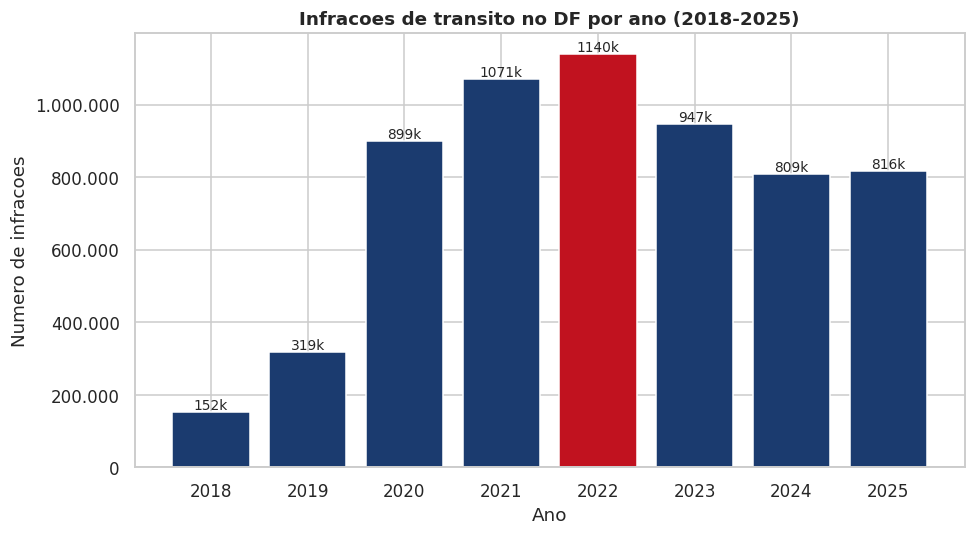

In [9]:
s = pd.Series(c_ano).sort_index()
fig, ax = plt.subplots(figsize=(9, 5))
cores = [ACENTO if a == s.idxmax() else PALETA for a in s.index]
ax.bar(s.index.astype(str), s.values, color=cores)
for x, v in enumerate(s.values):
    ax.text(x, v, f"{v/1000:.0f}k", ha="center", va="bottom", fontsize=9)
ax.set_title("Infracoes de transito no DF por ano (2018-2025)")
ax.set_xlabel("Ano"); ax.set_ylabel("Numero de infracoes")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(milhar))
plt.tight_layout(); plt.show()

**Leitura:** as infrações **crescem fortemente de 2018 a 2022**, quando atingem o pico
(~1,14 milhão), e depois **caem de forma consistente** até 2024, estabilizando em 2025. Os valores
baixos de 2018 (~152 mil) e 2019 (~319 mil) refletem **cobertura parcial** do dataset nesses anos
(o registro começa em jul/2018 e a fiscalização eletrônica ainda estava em expansão), então não devem
ser lidos como "havia pouca infração", mas sim "havia menos registro". A queda pós-2022, por outro
lado, ocorre com anos completos e é um sinal real.

### Gráfico 2 — Tipos de infração mais frequentes (pergunta secundária 1)

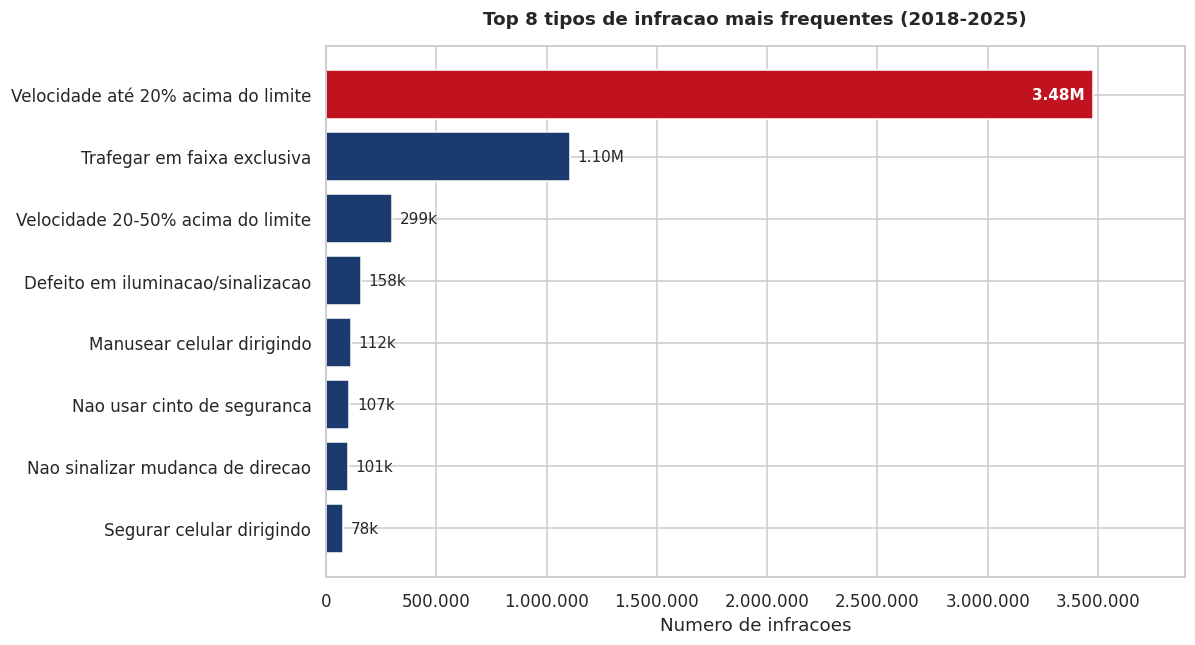

In [10]:
mapa_curto = {
    "Transitar em velocidade superior à máxima permitida em até 20%": "Velocidade até 20% acima do limite",
    "Transitar em velocidade superior à máxima permitida em mais de 20% até 50%": "Velocidade 20-50% acima do limite",
    "Transitar na faixa/pista da direita regul circulação exclusiva determ veículo": "Trafegar em faixa exclusiva",
    "Conduzir veíc c/ defeito no sist de iluminação, sinaliz ou lâmpadas queimadas": "Defeito em iluminacao/sinalizacao",
    "Dirigir veículo manuseando telefone celular": "Manusear celular dirigindo",
    "Dirigir veículo segurando telefone celular": "Segurar celular dirigindo",
    "Deixar o condutor de usar o cinto segurança": "Nao usar cinto de seguranca",
    "Deixar de indicar c/ antec, med gesto de braço/luz indicadora, mudança direção": "Nao sinalizar mudanca de direcao",
}
def encurtar(t):
    return mapa_curto.get(t, t if len(t) <= 40 else t[:37] + "...")

s = pd.Series(c_desc).drop(labels=["nan", "<NA>", "None"], errors="ignore")
s = s.sort_values(ascending=False).head(8).sort_values()
rot = [encurtar(t) for t in s.index]
cores = [ACENTO if v == s.max() else PALETA for v in s.values]
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(rot, s.values, color=cores)
xmax = s.max()
for i, v in enumerate(s.values):
    lbl = f"{v/1e6:.2f}M" if v >= 1e6 else f"{v/1000:.0f}k"
    if v > xmax * 0.6:
        ax.text(v - xmax*0.01, i, lbl, va="center", ha="right", color="white",
                fontsize=10, fontweight="bold")
    else:
        ax.text(v + xmax*0.01, i, lbl, va="center", fontsize=10)
ax.set_title("Top 8 tipos de infracao mais frequentes (2018-2025)", pad=14)
ax.set_xlabel("Numero de infracoes"); ax.set_xlim(0, xmax*1.12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(milhar))
plt.tight_layout(); plt.show()

**Leitura:** o dataset é **dominado por excesso de velocidade**. Sozinha, "velocidade até 20%
acima do limite" responde por ~3,5 milhões de autos — mais que todas as outras infrações somadas.
Isso indica que o registro vem majoritariamente de **fiscalização eletrônica (radares)**, que captura
velocidade automaticamente, enquanto infrações que dependem de abordagem (celular, cinto) aparecem em
volume muito menor.

### Gráfico 3 — Sazonalidade mensal (pergunta secundária 2)

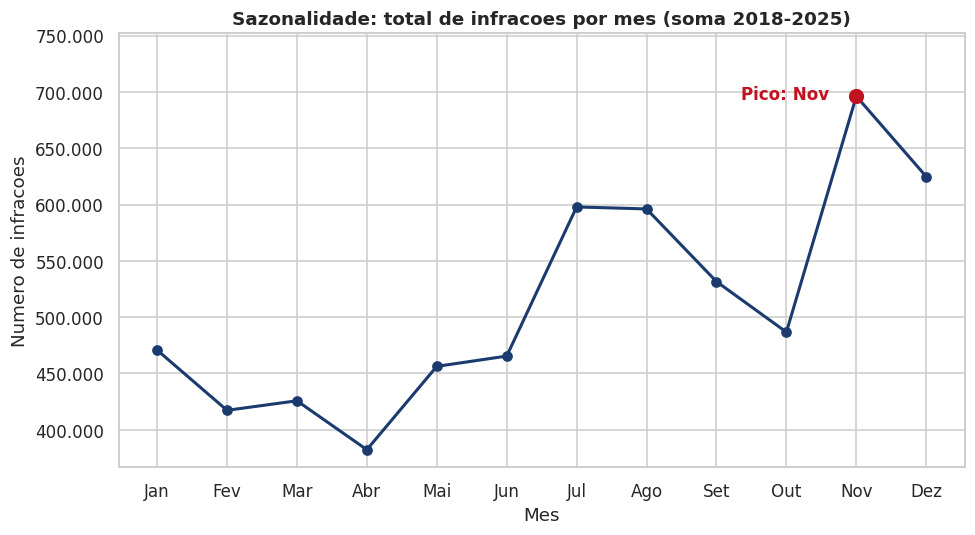

In [11]:
meses = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]
s = pd.Series(c_mes).reindex(range(1, 13)).fillna(0)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(meses, s.values, marker="o", color=PALETA, lw=2)
top = int(s.idxmax())
ax.scatter([top-1], [s.max()], color=ACENTO, zorder=5, s=80)
ax.annotate(f"Pico: {meses[top-1]}", (top-1, s.max()),
            textcoords="offset points", xytext=(-18, -2),
            ha="right", color=ACENTO, fontweight="bold")
ax.set_title("Sazonalidade: total de infracoes por mes (soma 2018-2025)")
ax.set_xlabel("Mes"); ax.set_ylabel("Numero de infracoes")
ax.set_ylim(top=s.max()*1.08)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(milhar))
plt.tight_layout(); plt.show()

**Leitura:** há **sazonalidade clara**. O volume é mais baixo no início do ano (abril é o vale)
e sobe no **segundo semestre**, com pico em **novembro** e forte presença de julho e dezembro. O padrão
coincide com períodos de maior circulação (férias de julho, festas de fim de ano) e campanhas de
fiscalização. Ressalva: é a soma de todos os anos; a forma geral é consistente, mas a magnitude de cada
mês sofre influência dos anos de maior registro (2020–2022).

### Gráfico 4 — Distribuição por gravidade

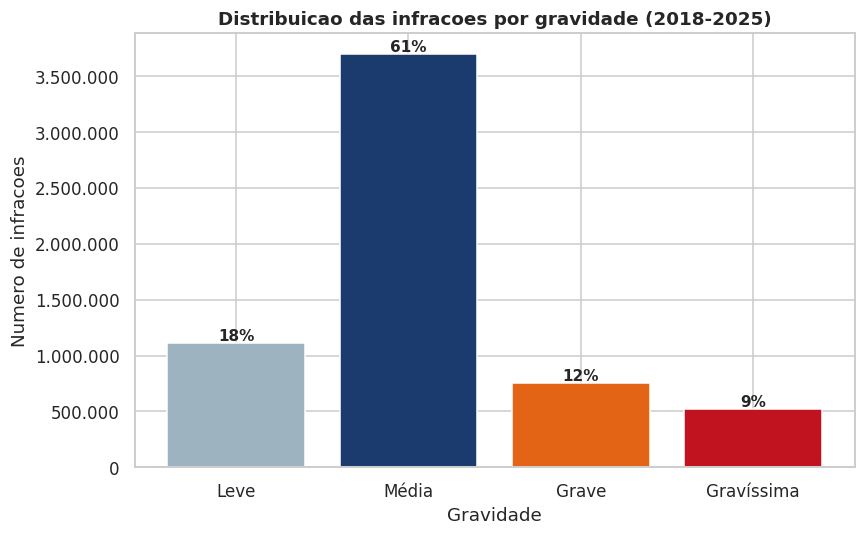

In [12]:
ordem = ["Leve", "Média", "Grave", "Gravíssima"]
s = pd.Series(c_grav).reindex(ordem).dropna()
cores = ["#9DB4C0", PALETA, "#E36414", ACENTO]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(s.index, s.values, color=cores[:len(s)])
total = s.sum()
for x, v in enumerate(s.values):
    ax.text(x, v, f"{v/total*100:.0f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
ax.set_title("Distribuicao das infracoes por gravidade (2018-2025)")
ax.set_xlabel("Gravidade"); ax.set_ylabel("Numero de infracoes")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(milhar))
plt.tight_layout(); plt.show()

**Leitura:** a maioria das infrações é de gravidade **Média (~61%)** — coerente com o domínio do
excesso de velocidade até 20%, classificado como média. As infrações **Grave + Gravíssima** somam cerca
de **21%**, fatia relevante associada a comportamentos de maior risco (alta velocidade, ultrapassagens
proibidas).

### Gráfico 5 — Infrações por tipo de veículo

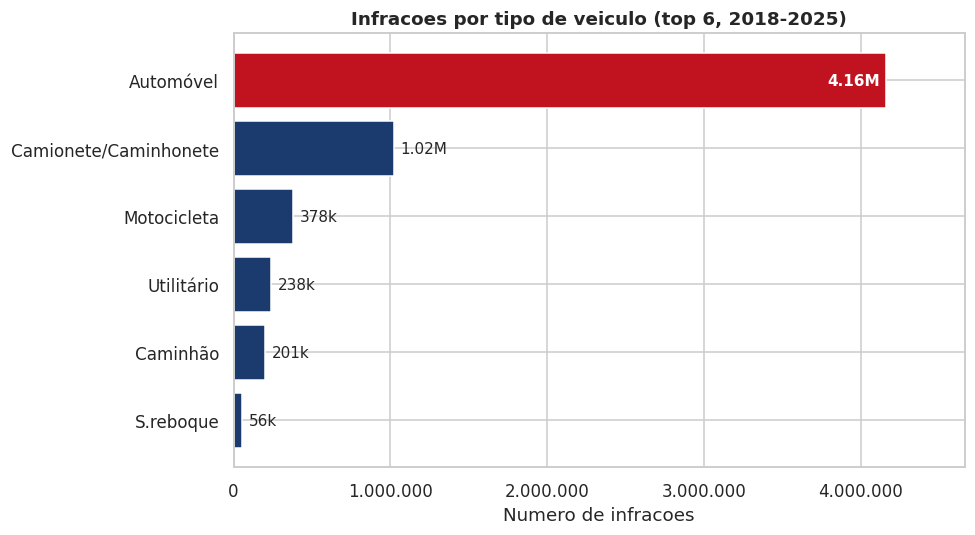

In [13]:
s = pd.Series(c_veic).drop(labels=["Não informado"], errors="ignore")
s = s.sort_values(ascending=False).head(6).sort_values()
cores = [ACENTO if v == s.max() else PALETA for v in s.values]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(s.index, s.values, color=cores)
xmax = s.max()
for i, v in enumerate(s.values):
    lbl = f"{v/1e6:.2f}M" if v >= 1e6 else f"{v/1000:.0f}k"
    if v > xmax*0.6:
        ax.text(v - xmax*0.01, i, lbl, va="center", ha="right", color="white",
                fontsize=10, fontweight="bold")
    else:
        ax.text(v + xmax*0.01, i, lbl, va="center", fontsize=10)
ax.set_title("Infracoes por tipo de veiculo (top 6, 2018-2025)")
ax.set_xlabel("Numero de infracoes"); ax.set_xlim(0, xmax*1.12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(milhar))
plt.tight_layout(); plt.show()

**Leitura:** o **automóvel** concentra a esmagadora maioria das infrações (~4,2 milhões), seguido
por camionetes/caminhonetes. Isso reflete a composição da frota do DF (predominância de automóveis de
passeio). O número **não** diz que automóveis "infringem mais por veículo" — apenas que, em volume
absoluto, são a maior fonte de autos registrados.

### Gráfico 6 — Distribuição por hora do dia

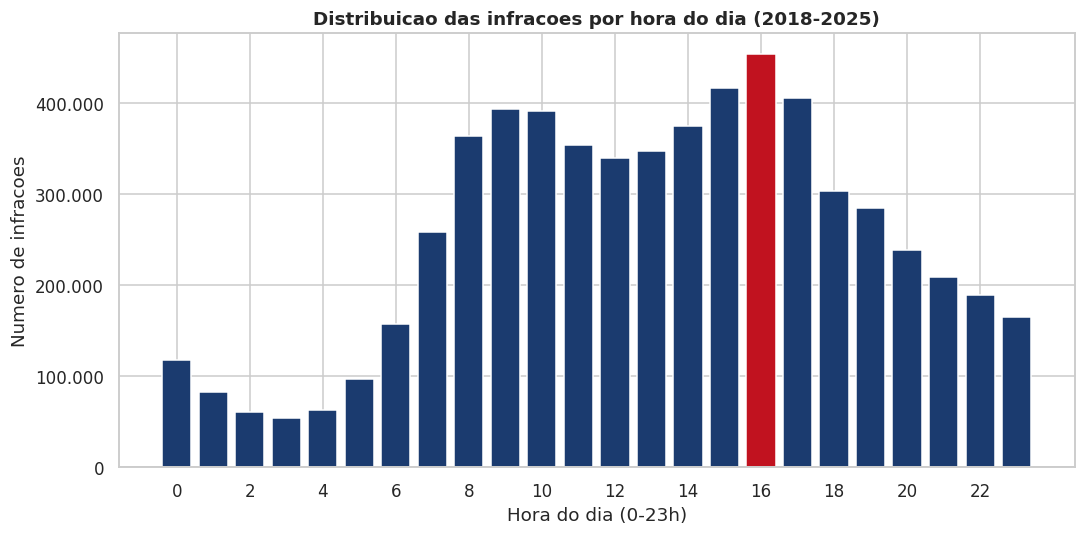

In [14]:
s = pd.Series(c_hora).reindex(range(24)).fillna(0)
fig, ax = plt.subplots(figsize=(10, 5))
pico_h = int(s.idxmax())
cores = [ACENTO if h == pico_h else PALETA for h in s.index]
ax.bar(s.index.astype(int), s.values, color=cores)
ax.set_title("Distribuicao das infracoes por hora do dia (2018-2025)")
ax.set_xlabel("Hora do dia (0-23h)"); ax.set_ylabel("Numero de infracoes")
ax.set_xticks(range(0, 24, 2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(milhar))
plt.tight_layout(); plt.show()

**Leitura:** as infrações se concentram no **período diurno**, com patamar alto entre **8h e 18h**
e pico por volta das **16–17h** — janela de maior fluxo (retorno do trabalho/escola). A madrugada
(2h–5h) tem o menor volume. O padrão acompanha a intensidade do tráfego ao longo do dia, não
necessariamente um horário "mais perigoso" por veículo em circulação.

## 4. Conclusões

**Conclusão 1 — As infrações cresceram até 2022 e vêm caindo desde então.**
A série anual (Gráfico 1) mostra pico em 2022 (~1,14 milhão) e queda consistente até 2024, com
estabilização em 2025. Respondendo à pergunta principal: a evolução **não é de crescimento contínuo** —
é de alta até 2022 seguida de retração. Ressalva honesta: 2018 e 2019 têm cobertura parcial do dataset,
então o "crescimento inicial" é em parte efeito de registro, não só de comportamento.

**Conclusão 2 — O dataset é dominado por excesso de velocidade captado por radar.**
Os Gráficos 2 e 4 mostram que "velocidade até 20% acima do limite" sozinha supera todas as demais
infrações somadas, e que ~61% dos autos são de gravidade Média. Isso indica que estes dados refletem
sobretudo **fiscalização eletrônica**, e não o conjunto completo de comportamentos de risco no trânsito.

**Conclusão 3 — Há padrões temporais e de perfil bem definidos.**
As infrações se concentram no **segundo semestre** (pico em novembro, Gráfico 3), no **período diurno
entre 8h e 18h** (pico 16–17h, Gráfico 6) e em **automóveis** (Gráfico 5). Esses padrões ajudam a
direcionar fiscalização e campanhas, mas medem **onde/quando há registro**, fortemente ligado ao fluxo
de veículos e à presença de radares — uma limitação que os dados abertos, sozinhos, não permitem separar.